In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.stats import weibull_min
from scipy.integrate import quad
from scipy.optimize import minimize_scalar, curve_fit

In [2]:
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)

In [4]:
# normalize power and speed
df['npower'] = df['power'] / df['power'].max()
df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())

# Deterministic Power Curve

$ Power = 0.5 * \rho * A * v^3 * C_p $

$\rho$ : density of air (kg/m^3) - standard is 1.225 kg/m^3

$A$ : cross sectional area of wind, swept area (m^2) (pyron is 4656.63 m^2)

$v$ : velocity of wind (m/s)

$C_p$ : coefficient of performance

In [5]:
rho = 1.225  # air density (kg/m^3)
A = np.pi * (77/2)**2  # swept area for Pyron (m^2)
P_rated = 1.5e6  # 1.5 MW in watts, 249 total for pyron
v_cut_in = 3.5
v_cut_out = 25
num_turbines = 163
C_p = 0.45

In [6]:
def power_curve(v):
    if v < v_cut_in or v > v_cut_out:
        return 0
    else:
        cut_in_val = (0.5 * rho * A * v_cut_in**3) * C_p * num_turbines / 1e6
        power = (0.5 * rho * A * v**3) * C_p * num_turbines / 1e6 - cut_in_val
        return min(power, 244.5)

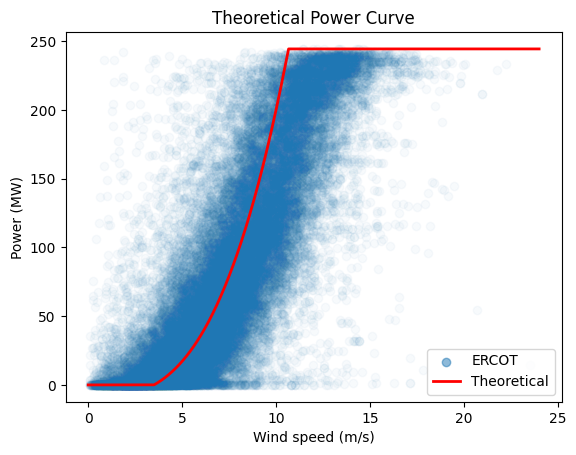

In [7]:
x = np.linspace(0, 24, 1000)
y = [power_curve(v) for v in x] # convert to MW

plt.scatter(df['speed'], df['power'], alpha=0.03, label='ERCOT')
plt.plot(x, y, label='Theoretical', color='red', linewidth=2)
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Theoretical Power Curve')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

## Pyron wake loss

In [16]:
np.set_printoptions(suppress=True, precision=6)

In [12]:
def PLF5(v, P, L, A, B, C):
    return L + (P - L) / (1 + (v / B) ** A) ** C

def PLF5_cut(v, P, L, A, B, C, cut_in=3.5):
    base = L + (P - L) / (1 + (v / B) ** A) ** C
    return np.where(v < cut_in, 0, base)

In [22]:
# coefficients of steady curve
popt, pcov = curve_fit(
    PLF5_cut,
    df['speed'],
    df['power_cf'] * 1.5,
    p0=[1.5, 0, -150, 10, 0.02],
    bounds=([1.5, -100, -1000, 0, 0.01], np.inf),
    maxfev=10000
)

In [23]:
popt

array([   1.500529,   -0.02286 , -109.005968,   10.884613,    0.027396])

In [8]:
# find wake loss in each region
dens = np.array([18, 38, 41, 18, 65, 60, 42, 42]) * 1e6 / (18.5 * 300 * 11 * 300)
loss = pd.DataFrame({
    'ref': [0, 1, 2, 3, 4, 5, 6, 8, 10],
    'loss': [0, 1, 1.7, 2.3, 2.8, 3.2, 3.5, 3.8, 3.9]
})

poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(loss['ref'].values.reshape(-1, 1))

model = LinearRegression()
model.fit(X_poly, loss['loss'])

dens_poly = poly_features.fit_transform(dens.reshape(-1, 1))
y_pred = model.predict(dens_poly)
loss_density = np.round(y_pred / dens, 3)

In [26]:
# percent wind loss from wake loss
shape, loc, scale = weibull_min.fit(df['speed'])

def power_loss(v, C):
    return 163 * weibull_min.pdf(v, shape, loc=loc, scale=scale) * PLF5_cut(v * C, *popt)

def optimal_wind(C, val):
    return abs(quad(power_loss, 0.0001, 100, args=(C,))[0]) / abs((quad(power_loss, 0.0001, 100, args=(1,))[0] - val))

wind_losses = []
for loss in loss_density:
    result = minimize_scalar(optimal_wind, bounds=(0.7, 1), args=(loss,), method='bounded')
    wind_loss = np.round(result.x, 3)
    wind_losses.append(wind_loss)

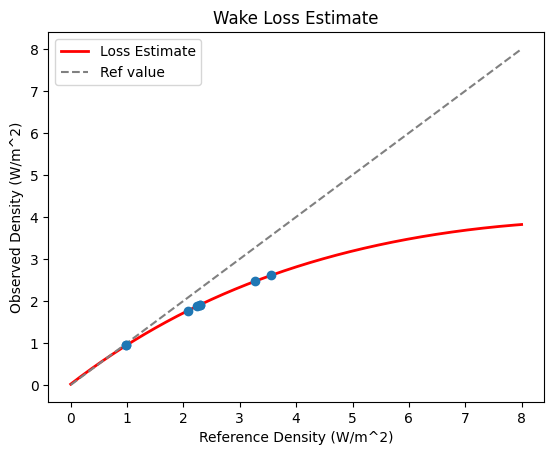

In [17]:
# curve for calculating wake loss
x = np.linspace(0, 8, num=1000)
y = model.predict(poly_features.fit_transform(x.reshape(-1, 1)))
plt.plot(x, y, label='Loss Estimate', color='red', linewidth=2)
plt.plot(x, x, label='Ref value', linestyle='--', color='gray')
plt.scatter(dens, y_pred, zorder=3)

plt.xlabel('Reference Density (W/m^2)')
plt.ylabel('Observed Density (W/m^2)')
plt.title('Wake Loss Estimate')
plt.legend()

##### calculate coefficients of wake loss curve

In [67]:
P_fixed = 1.5
L_fixed = -0.02119208
A_fixed = -159.94386670
B_fixed = 10.15037580
C_fixed = 0.01877349

weights = np.array([0.99 * 12, 25, 1, 12, 43, 16, 54])
wake_factors = np.array([0.976, 0.92, 0.913, 0.976, 0.86, 0.871, 0.91])

In [68]:
# 5 parameter logistic functions
def PLF5(v, P, L, A, B, C):
    return L + (P - L) / (1 + (v / B) ** A) ** C

def PLF5_cut(v, P, L, A, B, C, cut_in=3.5):
    base = L + (P - L) / (1 + (v / B) ** A) ** C
    return np.where(v < cut_in, 0, base)

def total_wake_power(X):
    return sum(
        w * PLF5(X * f, P_fixed, L_fixed, A_fixed, B_fixed, C_fixed)
        for w, f in zip(weights, wake_factors)
    )

def fit_model(X, P, L, A, B, C):
    return PLF5_cut(X, P, L, A, B, C)

In [ ]:
X = np.linspace(0, 25, 1000)
y = total_wake_power(X)

popt, pcov = curve_fit(
    fit_model,
    X,
    y,
    p0=[244.5, -4, -40, 11.2, 0.07],
    bounds=([244, -100, -1000, 8, 0.01], np.inf),
    maxfev=10000
)
print(popt)

[244.364282  -3.616128 -40.228351  11.213623   0.07438 ]


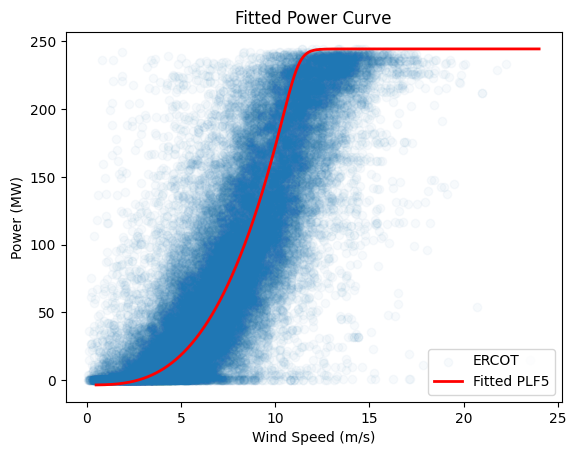

In [70]:
X = np.linspace(0.5, 24, 1000)
y = PLF5(X, *popt)

plt.scatter(df['speed'], df['power'], alpha=0.03, label='ERCOT')
plt.plot(X, y, label='Fitted PLF5', color='red', linewidth=2)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Fitted Power Curve')
plt.legend()

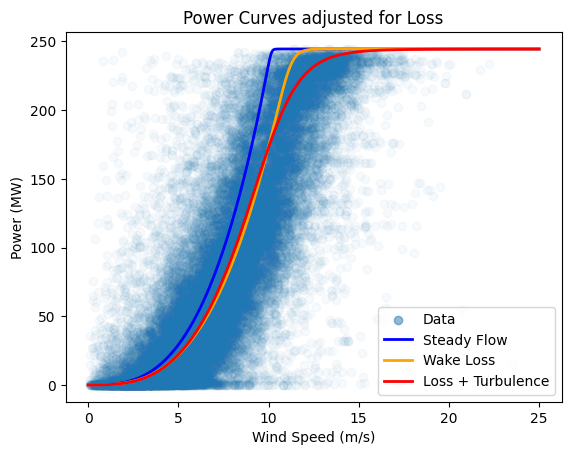

In [154]:
X = np.linspace(0, 25, 1000)
# y_st = 163 * PLF5(X, 1.5, -0.02181750, -161.50069891, 10.15104929, 0.01857233)
# y_wl = PLF5(X, 244.54466516, -3.57745000, -40.14553838, 11.21244215, 0.07457089)
# y_lt = PLF5(X, 244.4718239, -2.1593557, -10.9176942, 10.8237373, 0.2852041)
y_st = 163 * PLF5(X, 1.5, 0, -161.50069891, 10.15104929, 0.01857233)
y_wl = PLF5(X, 244.54466516, 0, -40.14553838, 11.21244215, 0.07457089)
y_lt = PLF5(X, 244.4718239, 0, -10.9176942, 10.8237373, 0.2852041)

plt.scatter(df['speed'], df['power'], alpha=0.03, label='Data')
plt.plot(X, y_st, label='Steady Flow', linewidth=2, color='blue')
plt.plot(X, y_wl, label='Wake Loss', linewidth=2, color='orange')
plt.plot(X, y_lt, label='Loss + Turbulence', linewidth=2, color='red')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Power Curves adjusted for Loss')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

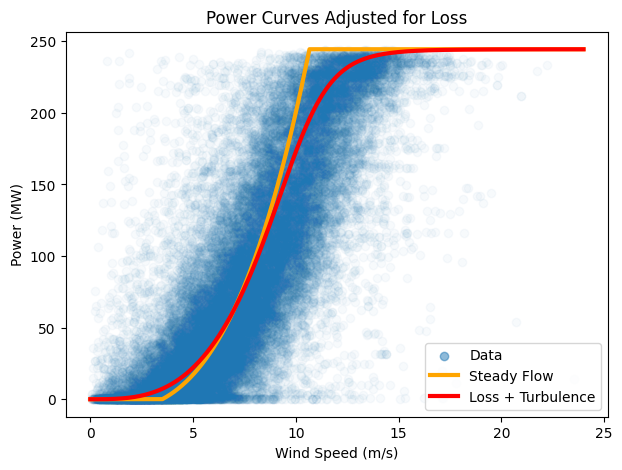

In [155]:
X = np.linspace(0, 24, 1000)
y = [power_curve(v) for v in X] # convert to MW
y_lt = PLF5(X, 244.4718239, 0, -10.9176942, 10.8237373, 0.2852041)

plt.figure(figsize=(7, 5))
plt.scatter(df['speed'], df['power'], alpha=0.03, label='Data')
plt.plot(X, y, label='Steady Flow', linewidth=3, color='orange')
plt.plot(X, y_lt, label='Loss + Turbulence', linewidth=3, color='red')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Power Curves Adjusted for Loss')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

# Time Series

In [ ]:
params = (244.4718239, 0, -10.9176942, 10.8237373, 0.2852041)
power_lt = PLF5(df['speed'], *params)

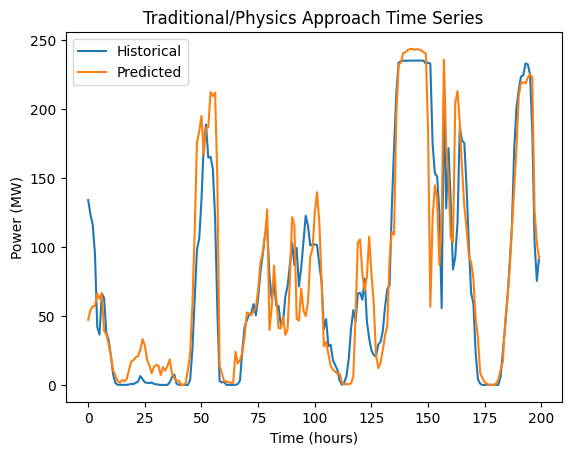

In [158]:
plt.plot(df['power'][:200], label='Historical')
plt.plot(power_lt[:200], label='Predicted')

plt.title('Traditional/Physics Approach Time Series')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

## with noise

In [159]:
from scipy.interpolate import make_splrep

In [160]:
df['power_lt'] = power_lt

In [103]:
# bin and fit std parameter to the historical power, as function of wind speed
def fit_std(speed, power, intervals, k=3, s=0):
    params = pd.DataFrame(columns=['avg_speed', 'std'])
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        avg_speed = (lower + upper) / 2
        filtered_power = power[(speed >= lower) & (speed < upper)]
        std = np.std(filtered_power)
        # print(std)
        params.loc[len(params)] = [avg_speed, std]
        # print(list(norm.fit(filtered_power, floc=0)))
        # params.loc[len(params)] = [avg_speed] + list(norm.fit(filtered_power, floc=10))

    std_spline = make_splrep(np.array(params['avg_speed']), np.array(params['std']), k=k, s=s)

    return std_spline

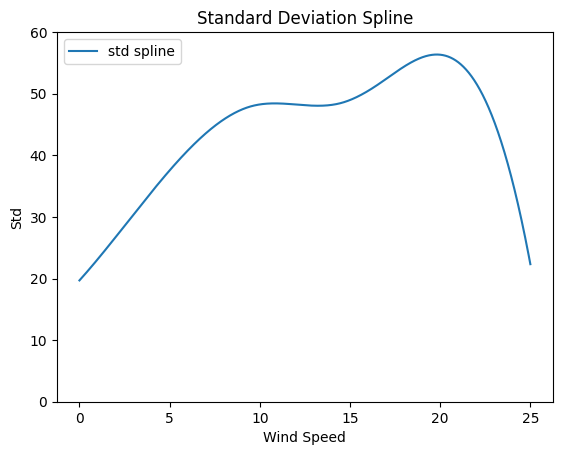

In [104]:
intervals = np.append(np.arange(0, 19, 1), 24)
std_spline = fit_std(df['speed'], df['power'], intervals, k=3, s=300)

x = np.linspace(0, 25, 10000)
y = std_spline(x)
plt.plot(x, y, label='std spline')
# plt.scatter(intervals[:-1], [std_spline(i) for i in intervals[:-1]], marker='o', label='std_spline points')
plt.title('Standard Deviation Spline')
plt.xlabel('Wind Speed')
plt.ylabel('Std')
plt.ylim(0, 60)
plt.legend()

In [184]:
# normal noise

def apply_noise(speed, power, std_spline):
    noise = np.random.normal(0, std_spline(speed), size=1)[0]
    init_power = power + noise
    if init_power < 0 or init_power > 244.5:
        noise = -noise / 3
        if power+noise < 0 or power+noise > 244.5:
            noise = 0
    return power + noise

power_noise = df.apply(lambda row: apply_noise(row['speed'], row['power_lt'], std_spline), axis=1)

In [185]:
power_noise.describe()

count    34856.000000
mean        98.127467
std         74.388915
min          0.004224
25%         30.795108
50%         79.975429
75%        164.381811
max        244.481437
dtype: float64

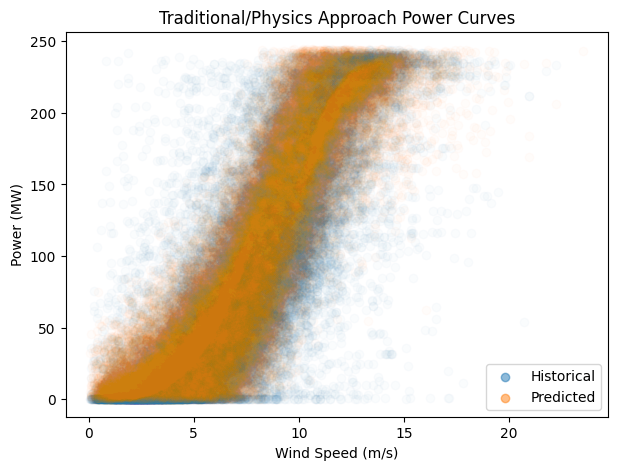

In [186]:
plt.figure(figsize=(7, 5))
plt.scatter(df['speed'], df['power'], alpha=0.02, label='Historical')
plt.scatter(df['speed'], power_noise, alpha=0.02, label='Predicted')

# x = np.linspace(0, 25, 1000)
# plt.plot(x, y_lt, color='red', label='Wake Loss Model', linewidth=2)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Traditional/Physics Approach Power Curves')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)
leg.legend_handles[1].set_alpha(0.5)

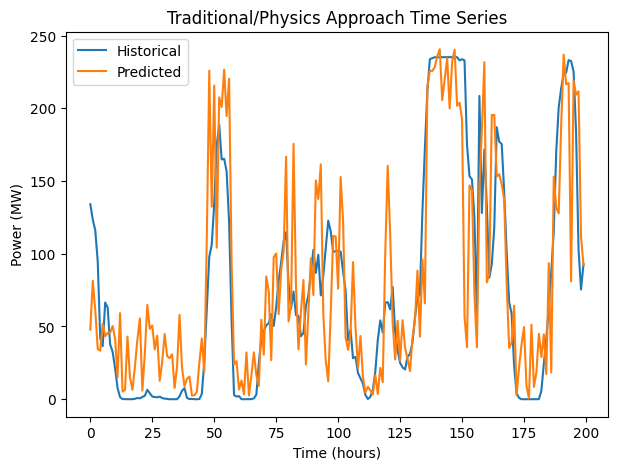

In [187]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][:200], label='Historical')
plt.plot(power_noise[:200], label='Predicted')
plt.title('Traditional/Physics Approach Time Series')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

## save csv for we-validate

In [129]:
from datetime import datetime, timedelta

In [ ]:
df['preds'] = power_noise
df['npreds'] = df['preds'] / 244.5

In [195]:
df.rename(columns={'datetime': 'time_stamp'}, inplace=True)

In [196]:
# generate time_stamps in order for we-validate compatibility
def generate_time_stamps(start_date):
    current = start_date
    time_stamps = []
    while len(time_stamps) < 34856:
        time_stamps.append(current.strftime('%Y-%m-%d %H:%M:%S'))
        current += timedelta(hours=1)
    return time_stamps

time_stamp = generate_time_stamps(datetime(2018, 1, 1, 1, 0, 0))
df['time_stamp'] = time_stamp

In [197]:
df

,time_stamp,speed,power_cf,power,npower,nspeed,power_lt,preds,npreds
0,2018-01-01 01:00:00,6.384246,0.191033,134.039,0.548825,0.268745,47.201255,47.792803,0.195472
1,2018-01-01 02:00:00,6.679563,0.220842,123.450,0.505468,0.281334,54.307007,81.397156,0.332913
2,2018-01-01 03:00:00,6.784414,0.232067,116.143,0.475550,0.285803,56.990286,61.163203,0.250156
3,2018-01-01 04:00:00,6.794198,0.233133,94.625,0.387444,0.286221,57.245032,34.449016,0.140896
4,2018-01-01 05:00:00,7.114358,0.269688,41.765,0.171008,0.299868,65.994587,33.327235,0.136308
...,...,...,...,...,...,...,...,...,...
34851,2021-12-23 04:00:00,2.544705,0.000000,5.338,0.021857,0.105072,2.694493,4.856703,0.019864
34852,2021-12-23 05:00:00,2.059370,0.000000,6.463,0.026463,0.084383,1.394158,0.375069,0.001534
34853,2021-12-23 06:00:00,3.659931,0.024277,10.312,0.042223,0.152612,8.354865,17.500533,0.071577
34854,2021-12-23 07:00:00,4.747566,0.070125,16.813,0.068841,0.198976,18.783456,23.486273,0.096058


In [198]:
df.to_csv('results/trad_physics_approach.csv', index=False)